# Goodreads Machine Learning - Group Project
------------
------------


## Decision/Actions Log (updated sequentially from below analysis)
1. clean raw data with 13 columns instead of 12 by concatenating authors column that spilled into average_rating column (fixed manually)
2. clean columns with leading/trailing spaces
3. clean publication_date column (2 errors found, fixed manually with isbn web search)


## 0. Import libraries & Helper functions
----------

In [184]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [185]:
def plot_distribution_with_mean(
    data,
    column,
    *,
    lower=0,
    upper=1500,
    title=None,
    xlabel=None,
    bins=40,
    color="#2a9d8f",
    mean_color="#e76f51",
    figsize=(9, 5),
    show_metrics=True,
):
    """Histogram + KDE with mean line, clipped to [lower, upper]."""
    series = data[column].dropna()
    series = series[(series >= lower) & (series <= upper)]

    col_mean = series.mean()
    col_std = series.std()

    plot_title = title or f"Distribution of {column} ({lower}–{upper})"
    plot_xlabel = xlabel or column

    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(series, bins=bins, kde=True, color=color, ax=ax)
    ax.axvline(
        col_mean,
        color=mean_color,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {col_mean:.3f}",
    )
    ax.set_xlim(lower, upper)
    ax.set_title(plot_title)
    ax.set_xlabel(plot_xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if show_metrics:
        display(pd.DataFrame({
            "metric": ["mean", "standard_deviation", "minimum", "maximum", "count"],
            "value": [col_mean, col_std, series.min(), series.max(), len(series)],
        }))

    return fig, ax

--------------------------------------
--------------------------------------
## 1. Loading Data
--------------------------------------
--------------------------------------

In [186]:
CSV_RAW_PATH = "../data/raw/books.csv"

In [187]:
df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


C:\Users\hugom\AppData\Local\Temp\ipykernel_18220\1247233899.py:1: ParserWarning: Skipping line 3350: expected 12 fields, saw 13
Skipping line 4704: expected 12 fields, saw 13
Skipping line 5879: expected 12 fields, saw 13
Skipping line 8981: expected 12 fields, saw 13

  df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


Upon inspection, the 4 errors came from the fact that the author string contained a comma "," which was interpreted as a new column and spilled the author name into the nex column when creating the .csv, thus resulting in 13 columns instead of 12

In [188]:
# the 4 errors were manualy fixed (joining the 2 columns with "," for these 4 error rows)
CSV_CLEANED_PATH = "../data/processed/books-hugo.csv" 
df = pd.read_csv(CSV_CLEANED_PATH, on_bad_lines='warn')

In [189]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


------------------------------------------
------------------------------------------
## 2. EDA & Cleaning Data
------------------------------------------
------------------------------------------

In [190]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11127 non-null  int64  
 1   title               11127 non-null  str    
 2   authors             11127 non-null  str    
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  str    
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  str    
 7     num_pages         11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  str    
 11  publisher           11127 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


### **observations :**
- It looks like there is a leading space for the " num_pages" column name
- isbn13 as int64 seems like the wrong type for and identifier, but not a big deal because we will probably drop these columns
- publication_date as string is not ideal, should be parsed to date

In [191]:
# check if bookID, ISBN, ISBN13 are all uniques
cols = ["bookID", "isbn", "isbn13"]
{col: df[col].is_unique for col in cols}

{'bookID': True, 'isbn': True, 'isbn13': True}

In [192]:
# since all are unique, we can select any for indexing, lets select bookID
df.set_index("bookID", inplace=True)

In [193]:
# fix column names
df.columns = df.columns.str.strip()

In [194]:
# test if any of the values contains leading/trailing spaces
for col in df.columns:
    if df[col].dtype == "str":
        has_spaces = df[col].dropna().ne(df[col].dropna().str.strip()).any()
        if has_spaces:
            print(f"Leading/trailing spaces detected in column: {col}")
        else:
            print(f"no spaces detected on column : {col}")



Leading/trailing spaces detected in column: title
no spaces detected on column : authors
no spaces detected on column : isbn
no spaces detected on column : language_code
no spaces detected on column : publication_date
no spaces detected on column : publisher


In [195]:
# fix publication_date, passing format to parse
pub_raw = df["publication_date"].copy()
df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    format="%m/%d/%Y",
    errors="coerce", # if the format is not correct, set to NaT
)
# check original values where the conversion failed
pub_raw.loc[df["publication_date"].isna()]

bookID
31373    11/31/2000
45531     6/31/1982
Name: publication_date, dtype: str

These dates are impossible, lets check ISBN code and look for the information on the internet since there is only 2 books with invalid dates

In [196]:
# check ISBN13 code
df.loc[df.publication_date.isna(), ["isbn","isbn13","title"]]

,isbn,isbn13,title
bookID,,,
31373,0553575104,9780553575101,In Pursuit of the Proper Sinner (Inspector Lyn...
45531,2070323285,9782070323289,Montaillou village occitan de 1294 à 1324


According to current goodreads.com: 
- *In Pursuit of the Proper Sinner* was puplished in October 31st, 2000
- *Montaillou  village occitan de 1294 à 1324* was published in June 30, 1982

One day is wrong by 1 day, the other by 1 month. 

These errors could be isolated, or might be a symptom of a larger issue with dates. Some of the parsable date might still be wrong. Goodreads.com does not provide a public API to check the data programmatically (an unofficial one exist on Apify), but there are other options to check the publishing date with Open Library or Google Books API.  

Lets apply a target fix:

In [197]:
# fix the dates by index
df.loc[31373, "publication_date"] = pd.to_datetime("2000-10-31")
df.loc[45531, "publication_date"] = pd.to_datetime("1982-06-30")

In [198]:
df.describe()

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date
count,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000,11127
mean,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498,2000-08-27 22:58:00.614721
min,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00
25%,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-16 12:00:00
50%,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000,2003-03-01 00:00:00
75%,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000,2005-09-30 00:00:00
max,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00
std,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608,NaN


At first glance, we can see that there are rows with num_pages, ratings_count and text_reviews_count equal to 0  
➜ should be investigated and cleaned

In [199]:
df.isna().sum()

title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

Check for other bad/empty data :

In [200]:
# check for bad data
bad_inputs = ["", "nan", "None", "N/A", "null", "-"]
bad_results = {}
for col in df.columns:
    mask = df[col].astype(str).str.strip().str.lower().isin(bad_inputs)
    bad_results[col] = int(mask.sum())
bad_results


{'title': 0,
 'authors': 0,
 'average_rating': 0,
 'isbn': 0,
 'isbn13': 0,
 'language_code': 0,
 'num_pages': 0,
 'ratings_count': 0,
 'text_reviews_count': 0,
 'publication_date': 0,
 'publisher': 0}

➜ no strictly missing values

In [201]:
print("num_pages zero count :",(df["num_pages"] == 0).sum())
print("ratings_count zero count :",(df["ratings_count"] == 0).sum())
print("text_reviews_count zero count :",(df["text_reviews_count"] == 0).sum())

num_pages zero count : 76
ratings_count zero count : 81
text_reviews_count zero count : 625


**Need to decide what to do with these :**

num_pages = 0 ➜ encode average/median?  
ratings_count = 0 ➜ drop  
text_reviews_count = 0 ➜ could be an actual signal, keep

## Looking for duplicates
------------------------

In [202]:
# top 10 duplicated titles
vc = df[["title","average_rating"]].value_counts()

In [203]:
# top 10 duplicated titles
vc = df[["title","authors","average_rating"]].value_counts()
print(vc.sum())
vc[vc > 1].head(10)

11127


title                                                                        authors                                 average_rating
Memoirs of a Geisha                                                          Arthur Golden                           4.11              5
One Hundred Years of Solitude                                                Gabriel García Márquez/Gregory Rabassa  4.07              5
'Salem's Lot                                                                 Stephen King                            4.02              5
White Teeth                                                                  Zadie Smith                             3.77              4
Sula                                                                         Toni Morrison                           3.93              4
The Scarlet Letter                                                           Nathaniel Hawthorne                     3.40              4
The Enemy (Jack Reacher  #8)                  

In [204]:
# check if there exist books with same title and authors, but different ratings
(df.groupby(["title","authors"])["average_rating"].nunique() > 1).any()

np.False_

Good news, duplicated books (by title & authors) all have the same ratings

In [205]:
df.loc[df["title"]=="Memoirs of a Geisha",["title","authors","publisher","isbn","language_code","average_rating"]]

,title,authors,publisher,isbn,language_code,average_rating
bookID,,,,,,
929,Memoirs of a Geisha,Arthur Golden,Vintage Books USA,1400096898,eng,4.11
930,Memoirs of a Geisha,Arthur Golden,Random House Large Print Publishing,0739326228,eng,4.11
931,Memoirs of a Geisha,Arthur Golden,Vintage,0099498189,en-US,4.11
933,Memoirs of a Geisha,Arthur Golden,Vintage,0099771519,eng,4.11
22278,Memoirs of a Geisha,Arthur Golden,Chatto & Windus,0701169699,eng,4.11


As seen earlier, there are no truly duplicated rows, but some of the rows only differ by publisher or language code : average_rating is the same when title & authors are the same

## Analysis : Average Rating (Target)
-----------

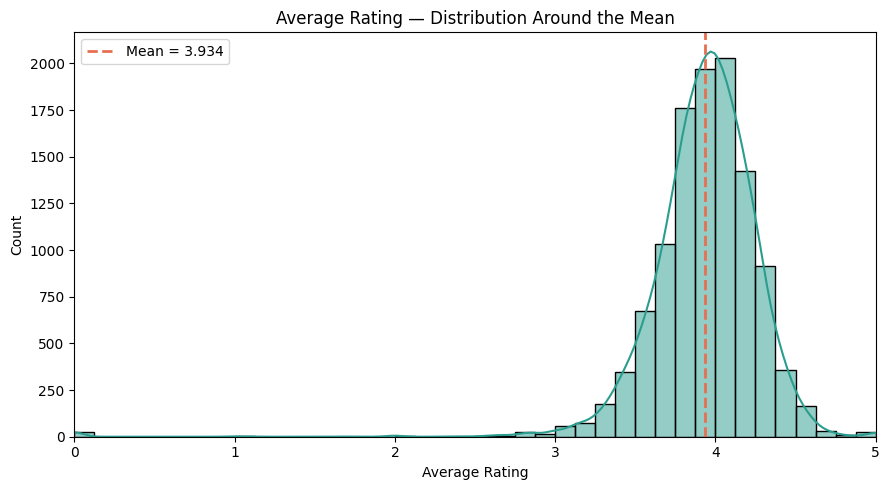

,metric,value
0,mean,3.933631
1,standard_deviation,0.352445
2,minimum,0.000000
3,maximum,5.000000
4,count,11127.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Average Rating — Distribution Around the Mean'}, xlabel='Average Rating', ylabel='Count'>)

In [206]:
plot_distribution_with_mean(
    df,
    column="average_rating",
    lower=0,
    upper=df["average_rating"].max(),
    title="Average Rating — Distribution Around the Mean",
    xlabel="Average Rating",
)

**Interpretation**  
- distribution is heavily centered around the average : 3.93  
- a few books appear with average rating being zero

In [207]:
print("average_rating negative count :",(df["average_rating"] < 0).sum())

average_rating negative count : 0


## Analysis : Ratings Count
-----------

In [208]:
print("ratings_count zero with average_rating not zero:",((df["ratings_count"] == 0) & (df["average_rating"] != 0)).sum())

ratings_count zero with average_rating not zero: 55


This is an issue, a book shouldn't have a positive rating if the ratings count is zero

In [209]:
df[(df["ratings_count"] == 0) & (df["average_rating"] != 0)].head()

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,,
797,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.03,8408064762,9788408064763,spa,480,0,0,2006-05-01,Geoplaneta
1658,American Government: Continuity and Change Al...,Karen O'Connor/Larry J. Sabato,2.83,0321317106,9780321317100,eng,664,0,0,2005-03-11,Longman Publishing Group
1664,Essentials of American and Texas Government: C...,Karen O'Connor/Larry J. Sabato,3.50,0321365208,9780321365200,eng,854,0,0,2005-07-29,Longman Publishing Group
2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0198145047,9780198145042,grc,364,0,0,1922-02-22,Oxford University Press USA
2411,Melville and the politics of identity: From *K...,Julian Markels,3.33,0252063023,9780252063022,eng,164,0,0,1993-07-01,University of Illinois Press


**Hypothesis :** 
From this snippet, we can hypothesize that the reason why these books have a rating > 0 while ratings_count = 0 is because books share the same rating accross original & translated versions. Lets test this hypothesis

In [210]:
# check if there are other books with the same title as the greek version of bookID 2034
title_2034 = df.loc[2034, "title"]
df["title"].eq(title_2034).sum()>1

np.False_

Hypothesis is wrong

## Analysis : Number of pages
-----------

Lets decide arbitrarily how many pages a book needs to have to be considered a real book

In [211]:
MIN_PAGES_COUNT = 5
MAX_PAGES_COUNT = 3000

In [212]:
print(
    f'books with less than {MIN_PAGES_COUNT} pages : {(df["num_pages"]<MIN_PAGES_COUNT).sum()}\n'
    f'books with more than {MAX_PAGES_COUNT} pages : {(df["num_pages"]>MAX_PAGES_COUNT).sum()}\n'
    f'books with zero pages : {(df["num_pages"] == 0).sum()}'
)
 

books with less than 5 pages : 132
books with more than 3000 pages : 5
books with zero pages : 76


In [213]:
df.loc[df["num_pages"]>MAX_PAGES_COUNT,["title","num_pages", "average_rating"]]

,title,num_pages,average_rating
bookID,,,
10,Harry Potter Collection (Harry Potter #1-6),3342,4.73
24520,The Complete Aubrey/Maturin Novels (5 Volumes),6576,4.70
25587,The Second World War,4736,4.45
25709,Summa Theologica 5 Vols,3020,4.12
44613,Remembrance of Things Past (Boxed Set),3400,4.34


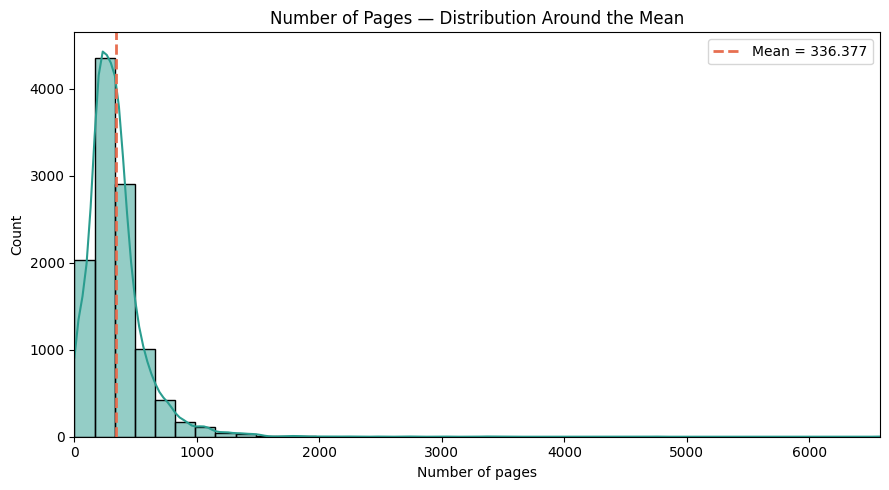

,metric,value
0,mean,336.376921
1,standard_deviation,241.127305
2,minimum,0.000000
3,maximum,6576.000000
4,count,11127.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Number of Pages — Distribution Around the Mean'}, xlabel='Number of pages', ylabel='Count'>)

In [214]:
# num_pages
plot_distribution_with_mean(
    df,
    column="num_pages",
    lower=0,
    upper=df["num_pages"].max(),
    title="Number of Pages — Distribution Around the Mean",
    xlabel="Number of pages",
)

## Analysis : Language Codes
------------

In [215]:
language_value_counts = df["language_code"].value_counts(dropna=False)
language_value_counts

language_code
eng      8911
en-US    1409
spa       218
en-GB     214
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        11
por        10
en-CA       7
ita         5
enm         3
lat         3
rus         2
swe         2
ara         1
nl          1
srp         1
msa         1
glg         1
wel         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [216]:
lang_values = language_value_counts.index.to_list()
lang_values

['eng',
 'en-US',
 'spa',
 'en-GB',
 'fre',
 'ger',
 'jpn',
 'mul',
 'zho',
 'grc',
 'por',
 'en-CA',
 'ita',
 'enm',
 'lat',
 'rus',
 'swe',
 'ara',
 'nl',
 'srp',
 'msa',
 'glg',
 'wel',
 'nor',
 'tur',
 'gla',
 'ale']

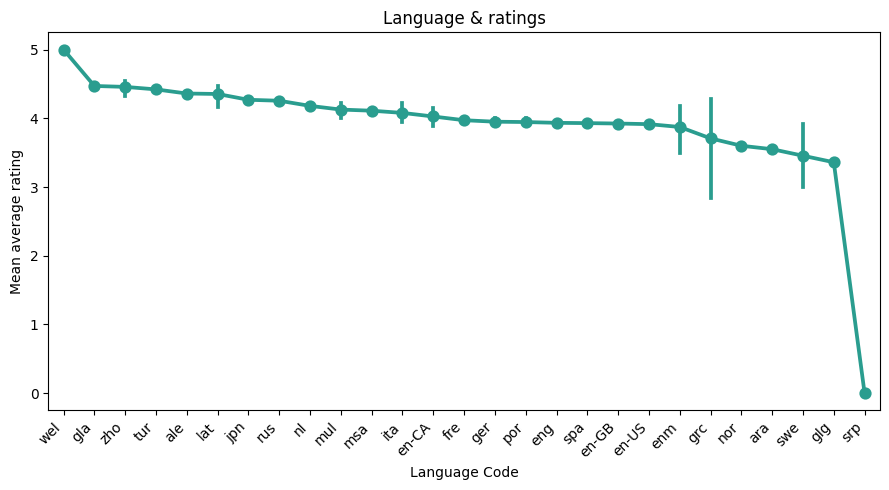

In [217]:
fig, ax = plt.subplots(figsize=(9, 5))

language_value_counts = df["language_code"].value_counts(dropna=False)

language_plot = df[["language_code", "average_rating"]].copy()

order = (
    language_plot.groupby("language_code", dropna=False)["average_rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.pointplot(
    data=language_plot,
    x="language_code",
    y="average_rating",
    order=order,
    errorbar=("ci", 95),
    color="#2a9d8f",
    ax=ax,
)
ax.set_title("Language & ratings")
ax.set_xlabel("Language Code")
ax.set_ylabel("Mean average rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [226]:
# check for multi-language books
multi_lang = (
    df.groupby(["title", "authors"])["language_code"]
    .agg(n_languages="nunique", languages=lambda s: sorted(s.dropna().unique()))
    .reset_index()
    .query("n_languages > 1")
    .sort_values("n_languages", ascending=False)
    .head(50)
)
multi_lang

,title,authors,n_languages,languages
342,A Tale of Two Cities,Charles Dickens/Gillen D'Arcy Wood,3,"[en-GB, en-US, eng]"
6059,Sahara (Dirk Pitt #11),Clive Cussler,3,"[en-US, eng, spa]"
5,'Salem's Lot,Stephen King,2,"[en-US, eng]"
422,Act of Treason (Mitch Rapp #9),Vince Flynn,2,"[en-US, eng]"
7,'Salem's Lot,Stephen King/Ron McLarty,2,"[en-US, eng]"
646,Angels & Demons (Robert Langdon #1),Dan Brown,2,"[en-US, eng]"
673,Anna Karenina,Leo Tolstoy/Richard Pevear/Larissa Volokhonsky,2,"[en-US, eng]"
725,Are We There Yet?,David Levithan,2,"[en-US, eng]"
795,At Risk (Winston Garano #1),Patricia Cornwell,2,"[en-US, eng]"
806,Atlas Shrugged,Ayn Rand,2,"[en-US, eng]"
